### About the dataset

Each row represents a customer (7043 overall), each column contains customer's attrributes.

Our target variable is `Churn` -> which is customers who left within a month.

Dataset includes:
- Services, that customer has signed up for (phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies)

- Customer account infomation (how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges) 

- Customer demographic information (gender, age range, and if they have partners and dependents)

- Target column: Churn

---

### Importing & exploring Dataset

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [82]:
df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')

In [83]:
df.head(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [84]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [85]:
df.shape

(7043, 21)

In [86]:
df.duplicated().any()

np.False_

In [87]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Based on exploration:
- there's no duplicates or NaN values
- 21 feature, 7043 rows
- some of the categorical features has 2 options, but also there're plenty with 3 or above
- there's only 2 numeric features in the dataset

---

### Encoding (Binary + OneHot)

In [88]:
two_unique_cols = df.columns[df.nunique() == 2]

In [89]:
df[two_unique_cols].head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,Female,0,Yes,No,No,Yes,No
1,Male,0,No,No,Yes,No,No
2,Male,0,No,No,Yes,Yes,Yes
3,Male,0,No,No,No,No,No
4,Female,0,No,No,Yes,Yes,Yes


We see that `SeniorCitizen` doesn't need encoding and that other columns except for `gender` having Yes / No options

In [90]:
pd.set_option('future.no_silent_downcasting', True)

In [91]:
binary = ['gender','Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
df[binary] = df[binary].replace({
    'Yes': 1, 'No': 0,
    'Male': 1, 'Female': 0
})

In [92]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,24,1,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,1,Mailed check,84.80,1990.5,0
7039,2234-XADUH,0,0,1,1,72,1,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,1,Credit card (automatic),103.20,7362.9,0
7040,4801-JZAZL,0,0,1,1,11,0,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,1,Electronic check,29.60,346.45,0
7041,8361-LTMKD,1,1,1,0,4,1,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Mailed check,74.40,306.6,1


---

In [93]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

In [94]:
onehot_cols = [
    'MultipleLines','InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'
]

In [95]:
df = pd.get_dummies(df, columns=onehot_cols, drop_first=True, dtype=int)

In [96]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,0,0,0,0,0,0,0,0,1,0
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,...,0,0,0,0,0,1,0,0,0,1
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,0,0,0,0,0,0,0,0,0,1
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,1,0,0,0,0,1,0,0,0,0
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,0,0,0,0,0,0,0,0,1,0


---

### Cleaning

So we have three problems:
- 1) ID column, which is not needed since it'll distort our models output
- 2) TotalCharges columns is actually object, not int / float
- 3) Our binary columns, created with boolean mask are also objects

In [97]:
df = df.drop(columns=['customerID'], axis=1)

In [98]:
df[binary] = df[binary].astype(int)

So we can't be 100% sure that our column contains only numeric values and not string -> we'll use `.to_numeric` since it handles sudden strings pretty well

In [99]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

Now we see that all columns are numerical. Let's drop the redundant ones

In [101]:
no_internet_cols = ['OnlineSecurity_No internet service', 'OnlineBackup_No internet service',
                    'DeviceProtection_No internet service', 'TechSupport_No internet service',
                    'StreamingTV_No internet service', 'StreamingMovies_No internet service',
                    'MultipleLines_No phone service']

In [102]:
df = df.drop(columns=no_internet_cols) 

In [114]:
# df.to_csv('../data/processed/Telco-Customer-Churn-Processed.csv', index=False)

---

In [103]:
X = df.drop(columns=['Churn'])

In [104]:
X = X.replace([np.inf,-np.inf], np.nan)
X = X.dropna()

---

### Correlation matrix and VIF (multicollinearity searching)

Since we have too many features we can't use just regular heatmap -> instead one-column heatmap

In [105]:
corr = df.corr(numeric_only=True)
churn_corr = corr[['Churn']].sort_values(by=['Churn'], ascending=False)

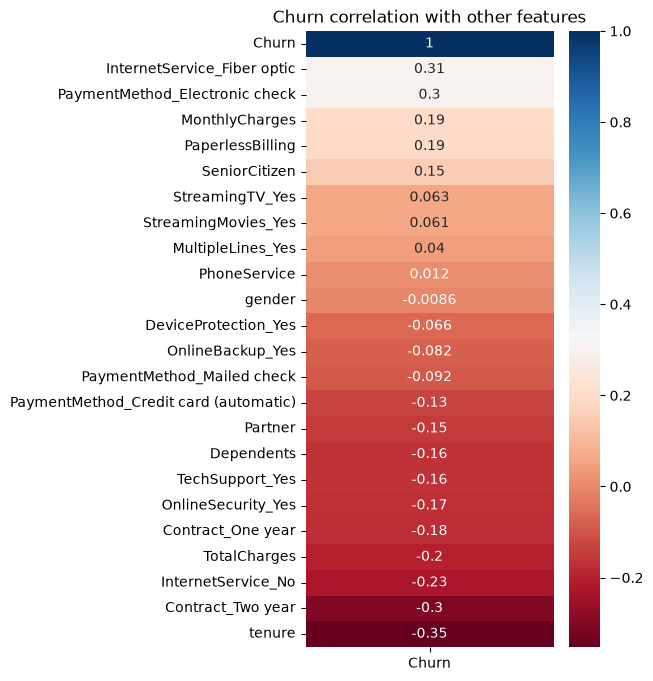

In [106]:
plt.figure(figsize=(4, 8))
sns.heatmap(churn_corr, annot=True, cmap='RdBu')

plt.title("Churn correlation with other features")
plt.show()

Based on heatmap we see, that customers who most likely to churn are those:
- With `Fiber Optic` as an internet service

- Who uses internet for paying (`Electronic check` and `Paperless billing`)
- Who's `senior`
- If they can't afford `too high prices`

---

On the other side, those who most likely not to churn are those
- who already have been `using services for a long time`

- who have `contract with company for a 2 years`
- who didn't pay for any additional internet services like `Streaming TV, Online Security, Online Backup etc.` -> the price for subscription is smaller

---

#### VIF part

In [107]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [108]:
vif_df = pd.DataFrame()
vif_df['feature'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_df = vif_df.sort_values(by='VIF', ascending=False)

print(vif_df)

                                  feature         VIF
7                          MonthlyCharges  212.353073
5                            PhoneService   47.244378
8                            TotalCharges   21.374002
4                                  tenure   20.482153
10            InternetService_Fiber optic   17.695260
11                     InternetService_No    8.234451
17                    StreamingMovies_Yes    5.090603
16                        StreamingTV_Yes    4.928957
19                      Contract_Two year    3.487502
14                   DeviceProtection_Yes    2.992570
6                        PaperlessBilling    2.956951
21         PaymentMethod_Electronic check    2.955994
13                       OnlineBackup_Yes    2.909898
9                       MultipleLines_Yes    2.861614
2                                 Partner    2.824725
15                        TechSupport_Yes    2.758343
12                     OnlineSecurity_Yes    2.682712
22             PaymentMethod

---

Based on VIF we see that:
- There're several features which are highly correlated (especially: `MonthlyCharges, PhoneService, TotalCharges, and tenure`)

- `MonthlyCharges` high value is expected since it's largely determined by the services a customer subscribes to.

- `TotalCharges and tenure` are high because  `TotalCharges` is actually `MonthlyCharges * tenure`

- Some of features has positive correlation like `InternetService_Fiber optic, InternetService_No`

As these relationships reflect the underlying business process rather than data quality issues, the multicollinearity won't be a problem since we'll use tree based model (`XGBoost` in our case). For linear models, their impact on coefficient stability should be considered

---